# B4 — Production Lattice Freeze


        B4는 새 최적화를 수행하는 단계가 아니다. B1–B3의 결과를 근거로
        이후 C-lite가 모든 sensor candidate에 사용할 **하나의 고정 follower
        solver 설정**을 선택하고 manifest로 잠그는 단계다.

In [1]:
from pathlib import Path
import json
from html import escape
import subprocess
import sys
from IPython.display import display, Markdown, Image, HTML, FileLink

def locate_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "p1b_4D").is_dir() and (candidate / "p1b_roadmap_0729.md").exists():
            return candidate
    raise RuntimeError("glider_hybrid_control repository root를 찾지 못했습니다.")

ROOT = locate_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / "results"
STAGE = "B4"
STATUS = "COMPLETED"

def run_module(module, *arguments, timeout=None):
    command = [sys.executable, "-m", module, *map(str, arguments)]
    completed = subprocess.run(
        command, cwd=ROOT, text=True, stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT, timeout=timeout,
    )
    print(completed.stdout)
    if completed.returncode != 0:
        raise RuntimeError(f"{module} 실행 실패: exit={completed.returncode}")
    return completed.stdout

def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"결과 파일이 없습니다: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def show_png(path, width=1050):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"> ⚠️ 그림이 없습니다: `{path}`"))

def display_table(rows, columns=None):
    if isinstance(rows, dict):
        rows = [rows]
    rows = list(rows)
    if columns is None:
        columns = []
        for row in rows:
            for key in row:
                if key not in columns:
                    columns.append(key)
    if not rows:
        display(Markdown("_(표시할 행이 없습니다.)_"))
        return
    def cell(value):
        if isinstance(value, float):
            value = f"{value:.8g}"
        elif isinstance(value, (dict, list, tuple)):
            value = json.dumps(value, ensure_ascii=False)
        return escape(str(value))
    header = "".join(f"<th>{cell(name)}</th>" for name in columns)
    body = "".join(
        "<tr>" + "".join(f"<td>{cell(row.get(name, ''))}</td>" for name in columns) + "</tr>"
        for row in rows
    )
    display(HTML(
        "<div style='overflow-x:auto'><table>"
        f"<thead><tr>{header}</tr></thead><tbody>{body}</tbody></table></div>"
    ))

display(Markdown(f"**{STAGE} 상태:** `{STATUS}`  \nRepository: `{ROOT}`"))

**B4 상태:** `COMPLETED`  
Repository: `C:\Users\jeffe\Desktop\git\glider_hybrid_control`

In [2]:
RERUN = False
B2_PATH = RESULTS / "direction_b" / "b2_two_hill_nested_consistency.json"
B3_PATH = RESULTS / "direction_b" / "b3_multiterrain_nested_consistency.json"
MANIFEST_PATH = RESULTS / "direction_b" / "b4_production_lattice_freeze.json"
FIGURE_PATH = RESULTS / "direction_b" / "figures" / "b4_production_lattice_freeze.png"
if RERUN:
    run_module(
        "p1b_4D.experiment_b4_production_lattice_freeze",
        "--b2-result", B2_PATH, "--b3-result", B3_PATH,
        "--output", MANIFEST_PATH,
    )
manifest = load_json(MANIFEST_PATH)
display(Markdown(
    f"**상태:** `{manifest['status']}`  \n"
    f"**Configuration ID:** `{manifest['production_configuration_id']}`  \n"
    f"**SHA-256:** `{manifest['manifest_sha256']}`"
))

**상태:** `complete`  
**Configuration ID:** `direction_b_l2_enriched_v9_q9_e1025`  
**SHA-256:** `62b573c6a029067fb68d52dde471bd93cf2c990e5f539665ec797f5e3685da44`

In [3]:
display_table([
    {"setting": key, "selected value": value}
    for key, value in manifest["selected_settings"].items()
])
terrain_rows = []
for terrain, settings in manifest["terrain_configurations"].items():
    terrain_rows.append({"terrain": terrain, **settings})
display_table(terrain_rows)
display_table([
    {"acceptance gate": key, "passed": value}
    for key, value in manifest["acceptance_gates"].items()
])

setting,selected value
action_family,enriched
endpoint_snapping,False
evaluator_sample_count,1025
level,2
planning_quadrature_count,9
speed_count,9
speed_family,V9
transition_model,successor_grid_physical_edge


terrain,configuration_id,configuration_sha256,continuous_replay_sample_count,endpoint_snapping,grid,movement,planning_quadrature_count,production_frozen,transition_model
goal_in_valley,direction_b_l2_enriched_v9_q9_e1025,a06840eed9e0360dc35700ce7d04687d144eb7e388d72f1d2c7d118583cbba68,1025,False,"{""h_count"": 201, ""h_spacing_m"": 1.0, ""position_node_count"": 93465, ""z_count"": 465, ""z_spacing_m"": 8.620689655172415}","{""displacement_direction_count"": 33, ""maximum_physical_envelope_m"": [137.93103448275863, 8.0], ""regular_action_count"": 297, ""speed_count"": 9, ""speed_values_mps"": [10.0, 11.575, 13.15, 14.725000000000001, 16.3, 17.875, 19.450000000000003, 21.025000000000002, 22.6]}",9,True,successor_grid_physical_edge
single_hill,direction_b_l2_enriched_v9_q9_e1025,0866b1afd76ebfd2eea5a18f6802606f4893a63d282ce33eebe3cc7cdab241d2,1025,False,"{""h_count"": 401, ""h_spacing_m"": 1.0, ""position_node_count"": 257041, ""z_count"": 641, ""z_spacing_m"": 8.59375}","{""displacement_direction_count"": 33, ""maximum_physical_envelope_m"": [137.5, 8.0], ""regular_action_count"": 297, ""speed_count"": 9, ""speed_values_mps"": [10.0, 11.575, 13.15, 14.725000000000001, 16.3, 17.875, 19.450000000000003, 21.025000000000002, 22.6]}",9,True,successor_grid_physical_edge
two_hill,direction_b_l2_enriched_v9_q9_e1025,555b979ffe829d56ac236171f033023769fb5940b1fc9b00f83a19c9635ffbc6,1025,False,"{""h_count"": 201, ""h_spacing_m"": 1.0, ""position_node_count"": 64521, ""z_count"": 321, ""z_spacing_m"": 8.59375}","{""displacement_direction_count"": 33, ""maximum_physical_envelope_m"": [137.5, 8.0], ""regular_action_count"": 297, ""speed_count"": 9, ""speed_values_mps"": [10.0, 11.575, 13.15, 14.725000000000001, 16.3, 17.875, 19.450000000000003, 21.025000000000002, 22.6]}",9,True,successor_grid_physical_edge


acceptance gate,passed
all_terrain_factories_validated,True
b2_case_count_is_18,True
b2_complete,True
b2_evaluator_gate_passed,True
b3_case_count_is_36,True
b3_complete,True
b3_evaluator_gate_passed,True
selected_settings_match_production_factory,True


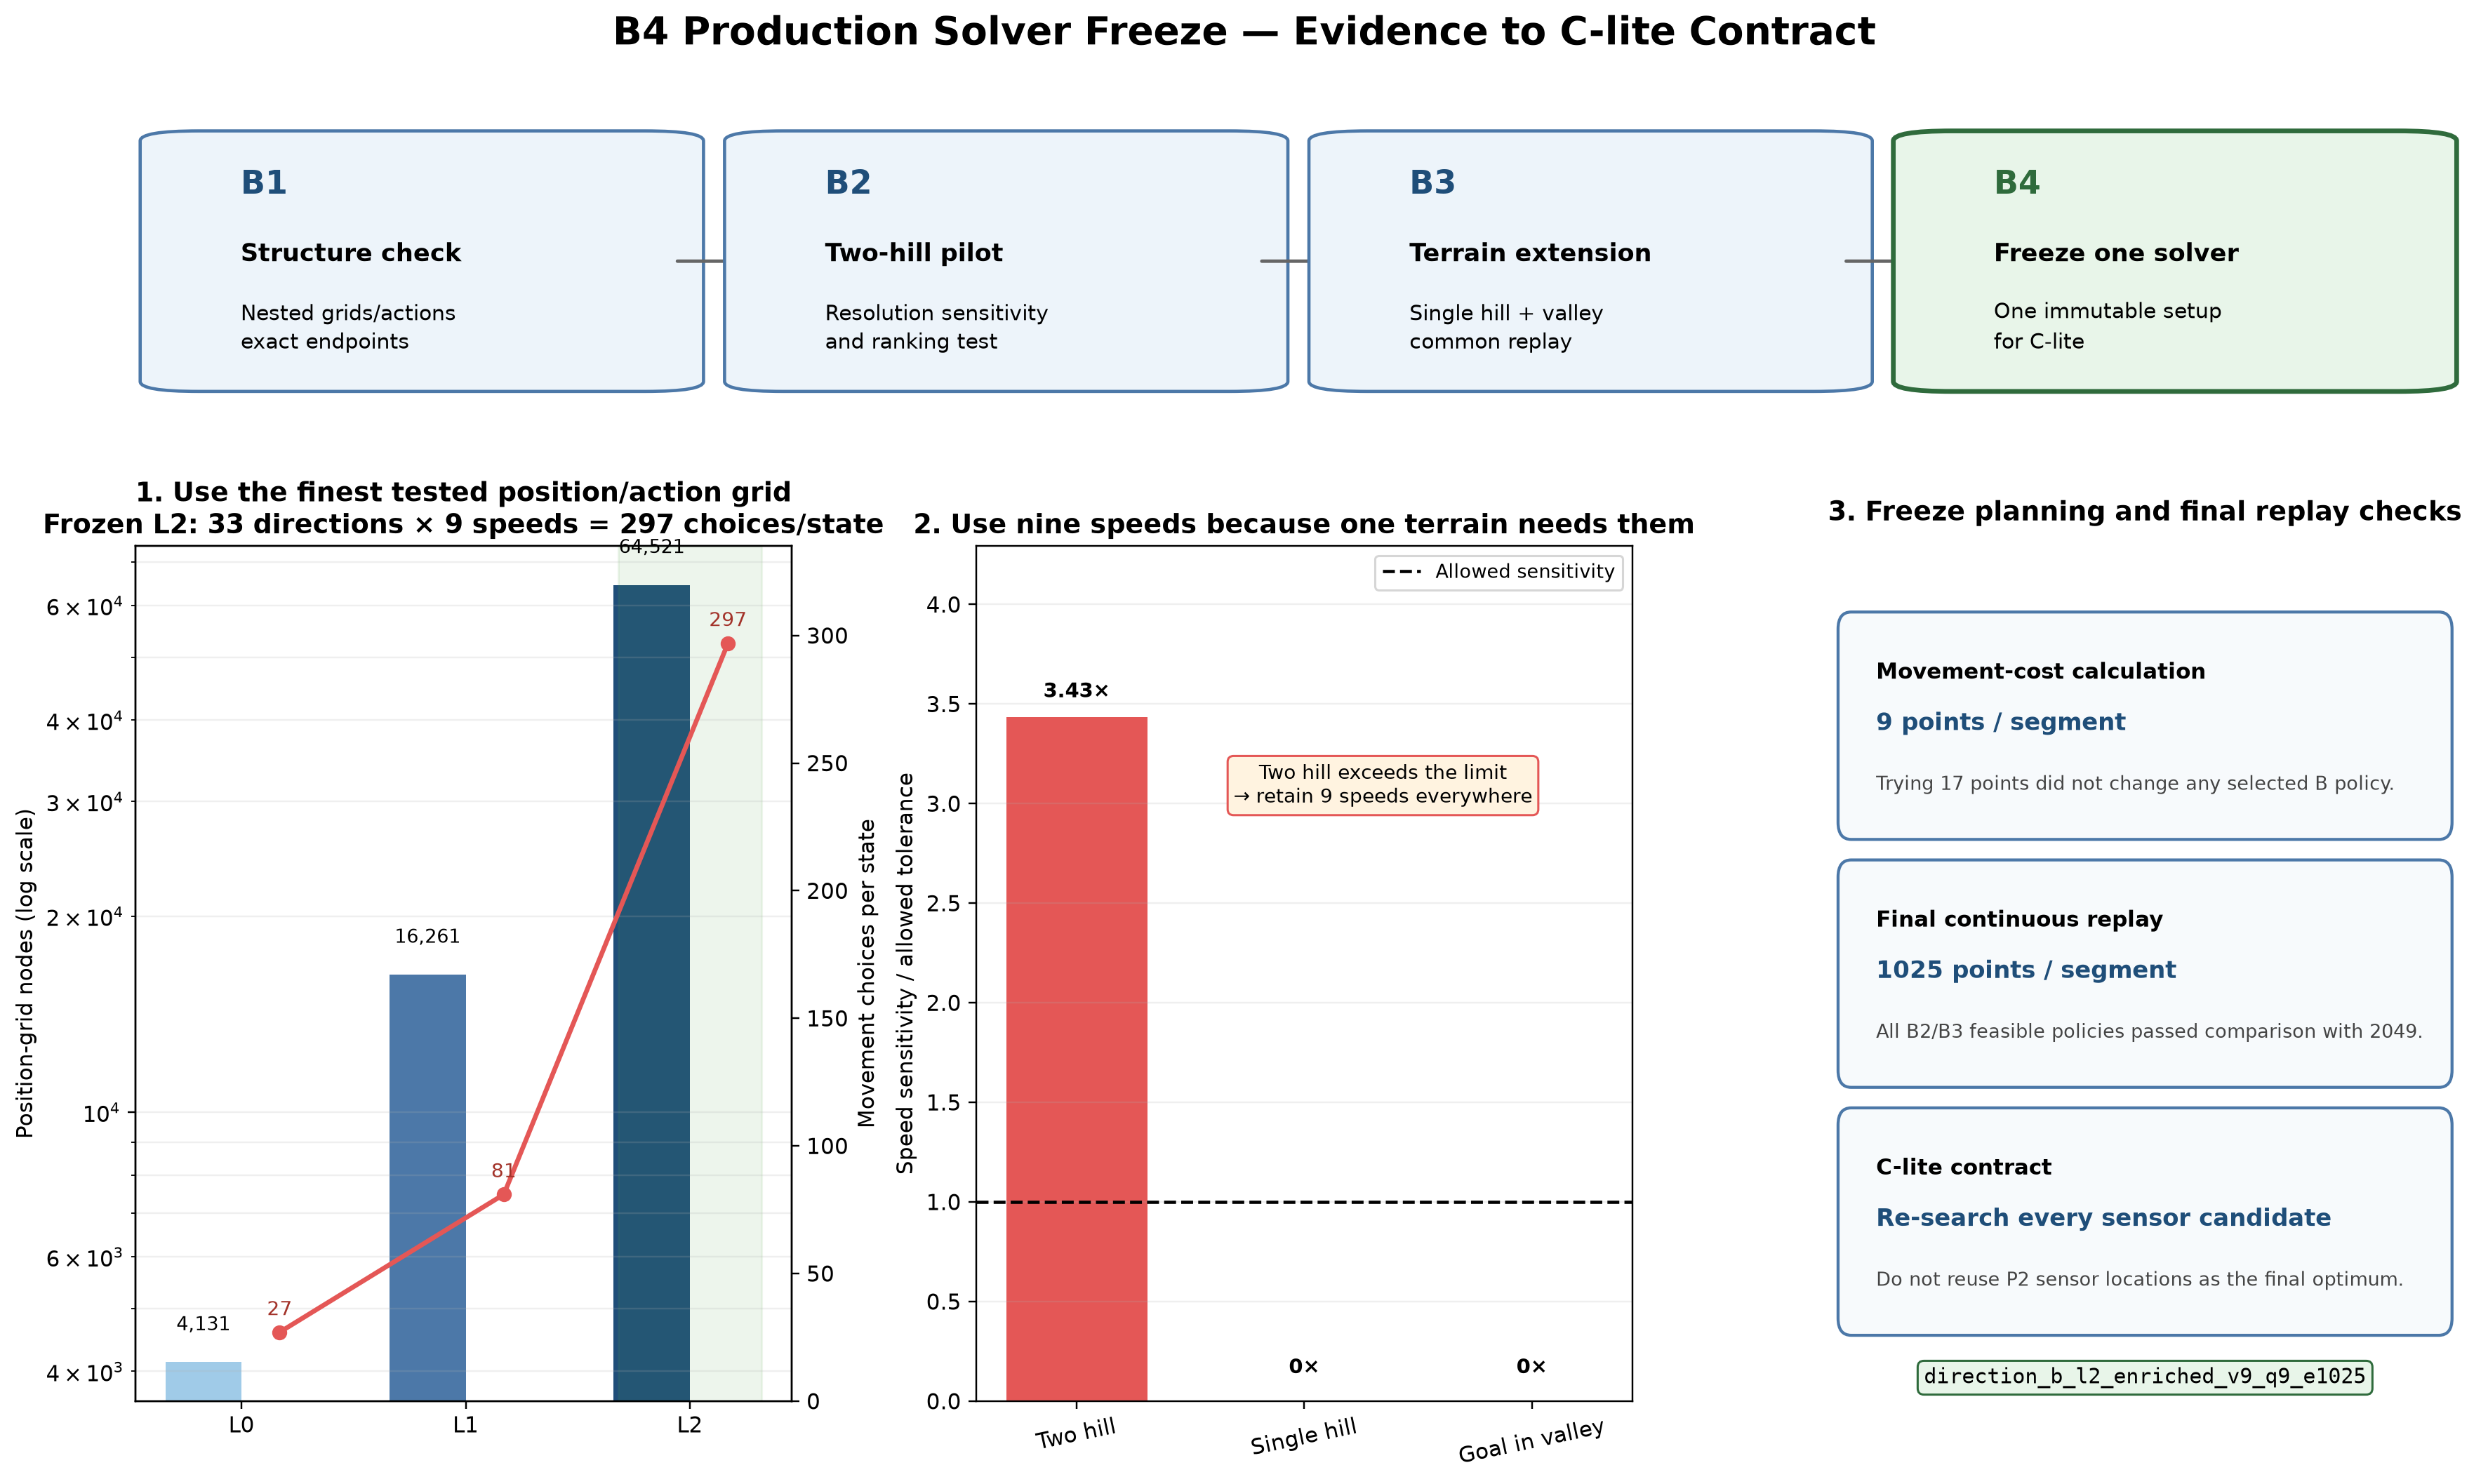

In [4]:
from p1b_4D.visualize_b4_production_lattice_freeze import create_b4_figure
create_b4_figure(MANIFEST_PATH, FIGURE_PATH)
show_png(FIGURE_PATH)

## 직관적 결론

C-lite는 L2 위치 격자, enriched 방향, 9개 속도, Q9 planning cost,
1025-point replay를 모든 leader 후보에 동일하게 사용해야 한다.
이 설정은 finite game contract이며 continuous optimum 주장이 아니다.